In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../Dataset/Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.drop(columns = ['RowNumber', 'CustomerId', 'Surname'], inplace = True)

In [4]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df = pd.get_dummies(df, columns =['Gender', 'Geography'], drop_first = True)

In [7]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Male,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,False,True


In [8]:
x = df.drop(columns='Exited', axis = 1)
y = df['Exited']

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y , test_size= 0.2 , random_state= 42)

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [12]:
x_train.shape, x_test.shape

((8000, 11), (2000, 11))

In [24]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [25]:
model = Sequential([
    Dense(12, activation = 'relu', input_dim = 11),
    Dense(12, activation = 'relu'),
    Dense(1, activation = 'sigmoid')
])

model.summary()

/Users/rachin/Desktop/Ai/ai2.0/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 12)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 313 (1.22 KB)

 Trainable params: 313 (1.22 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])
history = model.fit(x_train, y_train, epochs = 100, validation_data = (x_test, y_test))

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7079 - loss: 0.5811 - val_accuracy: 0.8045 - val_loss: 0.4703
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 784us/step - accuracy: 0.8004 - loss: 0.4622 - val_accuracy: 0.8120 - val_loss: 0.4288
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step - accuracy: 0.8069 - loss: 0.4387 - val_accuracy: 0.8215 - val_loss: 0.4132
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 795us/step - accuracy: 0.8204 - loss: 0.4205 - val_accuracy: 0.8265 - val_loss: 0.3940
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 766us/step - accuracy: 0.8350 - loss: 0.3964 - val_accuracy: 0.8470 - val_loss: 0.3730
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 730us/step - accuracy: 0.8459 - loss: 0.3748 - val_accuracy: 0.8480 - val_loss: 0.3611
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step - accuracy: 0.8519 - loss: 0.3617 - val_accuracy: 0.8555 - val_loss: 0.3524
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 682us/step - accuracy: 0.8547 - loss: 0.3

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

y_pred = model.predict(x_test)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step


In [28]:
y_pred = y_pred.argmax(axis = 1)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [29]:
accuracy = accuracy_score(y_pred, y_test)
accuracy

0.8035

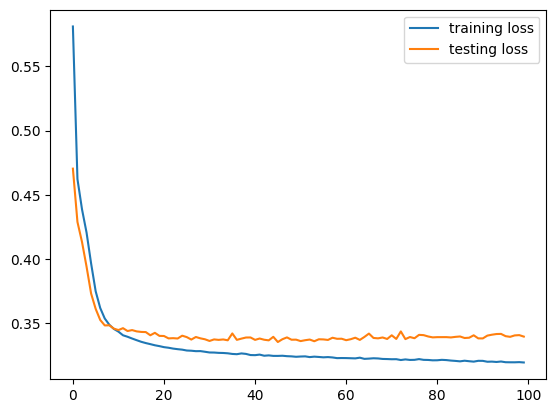

In [30]:
plt.plot(history.history['loss'], label = 'training loss')
plt.plot(history.history['val_loss'], label = 'testing loss')
plt.legend()
plt.show()

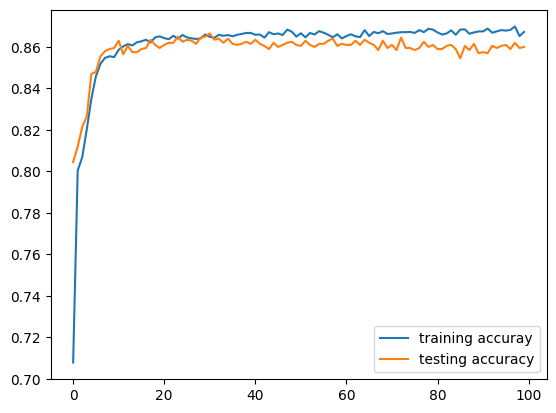

In [31]:
plt.plot(history.history['accuracy'], label = 'training accuray')
plt.plot(history.history['val_accuracy'], label = 'testing accuracy')
plt.legend()
plt.show()

In [32]:
model.layers[0]

<Dense name=dense_3, built=True>

In [34]:
model.layers[0].get_weights()

[array([[ 3.94811630e-02, -1.26869291e-01,  2.25139886e-01,
          3.58675197e-02,  2.10889414e-01,  1.19871333e-01,
         -1.46453097e-01,  5.22642910e-01,  9.16924253e-02,
          4.07117456e-01, -1.52333006e-01, -2.67244935e-01],
        [-1.13407843e-01, -1.31915743e-03, -4.06197309e-01,
         -4.10758406e-01, -6.34332359e-01, -9.26030576e-01,
          8.27326715e-01,  4.69135195e-01, -8.56760502e-01,
          4.17336375e-01,  8.45951319e-01,  8.14675510e-01],
        [ 4.04191352e-02, -1.27894044e-01,  1.69464156e-01,
         -3.29017565e-02,  6.11727051e-02, -4.59040515e-03,
         -1.89626627e-02,  4.95801002e-01,  1.95527032e-01,
         -1.18800206e-02, -2.08391715e-02, -2.16755301e-01],
        [ 1.53788492e-01,  2.08719280e-02,  3.66660893e-01,
         -7.01708913e-01, -2.97250934e-02, -5.28798521e-01,
         -7.19414353e-02, -4.33533221e-01, -4.07526761e-01,
          1.23642115e-02, -6.21226907e-01, -1.10372148e-01],
        [ 1.04527307e+00,  5.8351331